In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel('T2_A24_census5.xlsx', sheet_name='Sheet1')

# Data Cleaning Steps

# 1. Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 2. Standardize column names (remove spaces, make lowercase)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 3. Clean specific columns

# Clean house number - ensure it's numeric
df['house_number'] = pd.to_numeric(df['house_number'], errors='coerce')

# Clean street names - standardize formatting
df['street'] = df['street'].str.strip()

# Clean names - remove extra spaces
df['first_name'] = df['first_name'].str.strip()
df['surname'] = df['surname'].str.strip()

# Clean age - ensure numeric and reasonable values
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = df['age'].apply(lambda x: x if 0 <= x <= 120 else np.nan)


# Clean marital status - standardize values
marital_status_mapping = {
    'Single': 'Single',
    'Married': 'Married',
    'Divorced': 'Divorced',
    'Widowed': 'Widowed',
    '': 'Unknown'
}
df['marital_status'] = df['marital_status'].str.strip()
df['marital_status'] = df['marital_status'].replace(marital_status_mapping)
df['marital_status'] = df['marital_status'].fillna('Unknown')

# Clean gender - standardize values
df['gender'] = df['gender'].str.strip()
df['gender'] = df['gender'].replace({'Female': 'Female', 'Male': 'Male'})

# Clean occupation - standardize missing values and formatting
df['occupation'] = df['occupation'].str.strip()
df['occupation'] = df['occupation'].replace('', np.nan)
df['occupation'] = df['occupation'].fillna('Unknown')

# Clean infirmity - standardize missing values
df['infirmity'] = df['infirmity'].str.strip()
df['infirmity'] = df['infirmity'].replace('', np.nan)
df['infirmity'] = df['infirmity'].fillna('None')

# Clean religion - standardize values and missing data
df['religion'] = df['religion'].str.strip()
religion_mapping = {
    'No Religion': 'None',
    'Christian': 'Christian',
    'Sikh': 'Sikh',
    'Hindu': 'Hindu',
    'Muslim': 'Muslim',
    'Church of England': 'Christian',
    '': 'Unknown'
}
df['religion'] = df['religion'].replace(religion_mapping)
df['religion'] = df['religion'].fillna('Unknown')

# 4. Handle missing values for age based on relationship
# Children with missing age are likely young (0-17), set to median child age
child_mask = df['relationship_to_head_of_house'].isin(['Child', 'Grandchild', 'Stepchild', 'Adopted Child'])
median_child_age = df[child_mask]['age'].median()
df.loc[child_mask & df['age'].isna(), 'age'] = median_child_age

# Adults with missing age set to median adult age
adult_mask = ~child_mask
median_adult_age = df[adult_mask]['age'].median()
df.loc[adult_mask & df['age'].isna(), 'age'] = median_adult_age

# 5. Create additional useful columns
# Family identifier - combination of house number and street
df['family_id'] = df['house_number'].astype(str) + '_' + df['street']

# Age group categorization
bins = [0, 17, 64, 120]
labels = ['Child', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# 6. Final check for any remaining issues
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# 7. Save cleaned data
df.to_excel('cleaned_census_data.xlsx', index=False)

print("\nData cleaning complete. Cleaned data saved to 'cleaned_census_data.xlsx'")

Missing values before cleaning:
House Number                        0
Street                              0
First Name                          0
Surname                            12
Age                                 0
Relationship to Head of House     705
Marital Status                   2437
Gender                              0
Occupation                          0
Infirmity                        9789
Religion                         1300
dtype: int64

Missing values after cleaning:
house_number                       0
street                             0
first_name                         0
surname                           12
age                                0
relationship_to_head_of_house    705
marital_status                     0
gender                             0
occupation                         0
infirmity                          0
religion                           0
family_id                          0
age_group                          0
dtype: int64

Data clean

In [2]:
import pandas as pd

# Load the dataset
data = pd.read_excel('cleaned_census_data.xlsx')

# Task (a): Determine what to build on the unoccupied plot of land

# 1. High-density housing: Check if the population is significantly expanding
# - Analyze family sizes and number of children
family_sizes = data['family_id'].value_counts()
average_family_size = family_sizes.mean()
children_count = data[data['age_group'] == 'Child'].shape[0]
total_population = data.shape[0]
children_percentage = (children_count / total_population) * 100

# 2. Low-density housing: Check if the population is affluent
# - Analyze occupations for high-income professions (e.g., engineers, doctors, managers)
affluent_occupations = ['engineer', 'doctor', 'manager', 'director', 'analyst', 'consultant', 'financial', 'architect']
affluent_count = data['occupation'].str.contains('|'.join(affluent_occupations), case=False, na=False).sum()
affluent_percentage = (affluent_count / total_population) * 100

# 3. Train station: Identify commuters
# - Commuters can be identified by occupations that likely require travel (e.g., 'manager', 'analyst', 'consultant', 'teacher')
commuter_occupations = ['manager', 'analyst', 'consultant', 'teacher', 'administrator', 'officer']
commuter_count = data['occupation'].str.contains('|'.join(commuter_occupations), case=False, na=False).sum()
commuter_percentage = (commuter_count / total_population) * 100

# 4. Religious building: Analyze religious demographics
religion_counts = data['religion'].value_counts()
current_catholic_count = religion_counts.get('Christian', 0)
other_religions = religion_counts.drop('Christian', errors='ignore')

# 5. Emergency medical building: Check health needs
# - Injuries: Look for 'Disabled' or 'Infirmity' entries
injuries_count = data['infirmity'].notna().sum()
# - Future pregnancies: Count women of childbearing age (18-45)
childbearing_age_women = data[(data['gender'] == 'Female') & (data['age'] >= 18) & (data['age'] <= 45)].shape[0]

# Print analysis results
print("Analysis Results:")
print(f"- Average family size: {average_family_size:.2f}")
print(f"- Percentage of children in population: {children_percentage:.2f}%")
print(f"- Percentage of affluent occupations: {affluent_percentage:.2f}%")
print(f"- Percentage of potential commuters: {commuter_percentage:.2f}%")
print("- Religious demographics:")
print(religion_counts)
print(f"- Number of individuals with infirmities: {injuries_count}")
print(f"- Women of childbearing age (18-45): {childbearing_age_women}")

# Determine the best option
recommendation = None
justification = []

if children_percentage > 20:  # Threshold for significant population growth
    recommendation = "High-density housing"
    justification.append(f"Population is expanding (children make up {children_percentage:.2f}% of the population).")
elif affluent_percentage > 30:  # Threshold for affluent population
    recommendation = "Low-density housing"
    justification.append(f"Affluent population detected ({affluent_percentage:.2f}% in high-income occupations).")
elif commuter_percentage > 40:  # Threshold for significant commuter population
    recommendation = "Train station"
    justification.append(f"High number of potential commuters ({commuter_percentage:.2f}% in commuting occupations).")
elif other_religions.sum() > current_catholic_count * 0.5:  # Threshold for other religious demand
    recommendation = "Religious building"
    justification.append(f"Diverse religious demographics with significant non-Christian populations: {other_religions.to_dict()}.")
elif injuries_count > total_population * 0.1 or childbearing_age_women > total_population * 0.2:  # Threshold for health needs
    recommendation = "Emergency medical building"
    justification.append(f"Significant health needs: {injuries_count} infirmities and {childbearing_age_women} women of childbearing age.")
else:
    recommendation = "Community center or park"
    justification.append("No immediate priority identified; a community center or park could improve quality of life.")

print("\nRecommendation:")
print(recommendation)
print("\nJustification:")
print("\n".join(justification))

Analysis Results:
- Average family size: 2.99
- Percentage of children in population: 23.84%
- Percentage of affluent occupations: 13.32%
- Percentage of potential commuters: 14.49%
- Religious demographics:
religion
Christian       4291
Unknown         1300
Muslim           114
Hindu             91
Sikh              50
The Chantry        2
Jewish             1
Buddist            1
Athiest            1
Greek              1
The Templars       1
Humanist           1
Name: count, dtype: int64
- Number of individuals with infirmities: 109
- Women of childbearing age (18-45): 2268

Recommendation:
High-density housing

Justification:
Population is expanding (children make up 23.84% of the population).


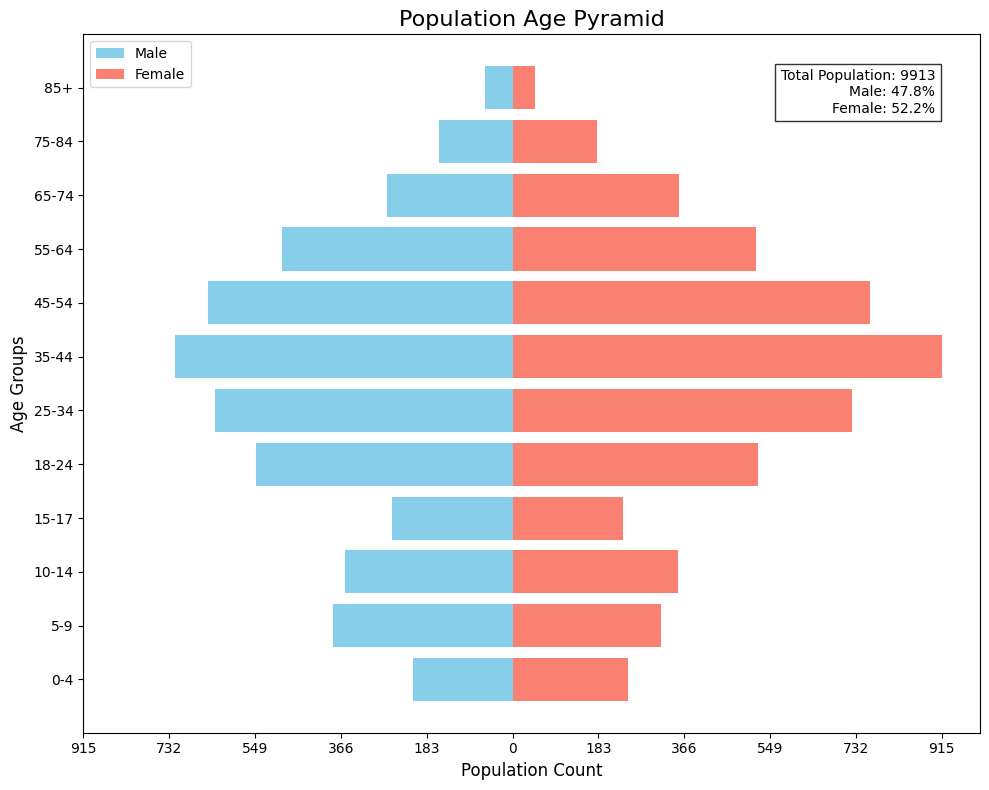


Age Distribution Analysis:
-------------------------
Total population: 9913
Children (0-17): 2503 (25.2%)
Working age (18-64): 6420 (64.8%)
Seniors (65+): 990 (10.0%)

Dependency Ratios:
Child dependency ratio (children per working-age adult): 0.39
Senior dependency ratio (seniors per working-age adult): 0.15
Total dependency ratio: 0.54

Potential retirees in next 20 years (current 45-64 year olds): 2326

Population pyramid saved as 'age_pyramid.png'


C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:108: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unemployment = df.groupby('age_group')['is_unemployed'].agg(['sum', 'count'])


<Figure size 640x480 with 0 Axes>

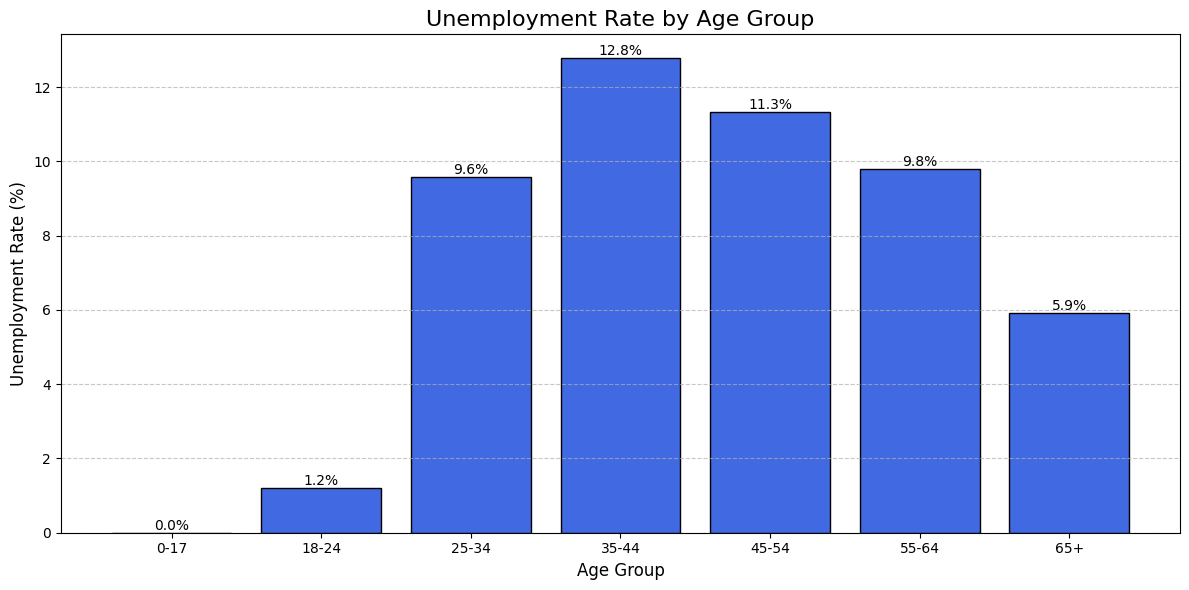

C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:134: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_unemployment = df.groupby(['age_group', 'gender'])['is_unemployed'].agg(['sum', 'count'])


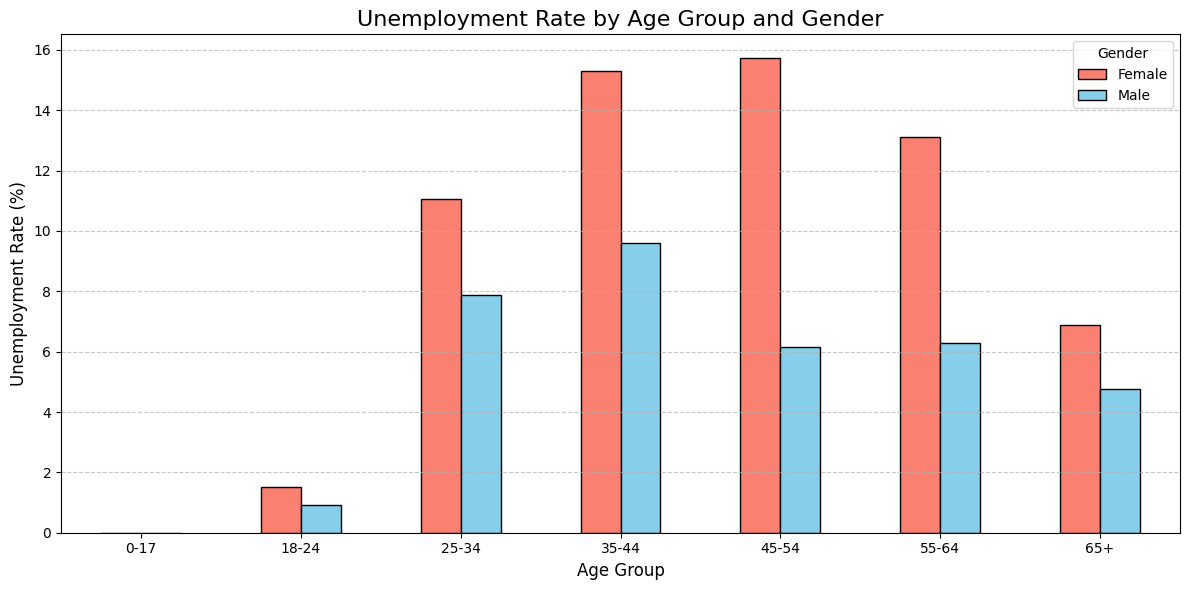


Unemployment Analysis by Age Group:
----------------------------------
  age_group  Unemployed  Total   Rate (%)
0      0-17           0   2363   0.000000
1     18-24          13   1071   1.213819
2     25-34         130   1357   9.579956
3     35-44         209   1635  12.782875
4     45-54         160   1412  11.331445
5     55-64          99   1011   9.792285
6       65+          63   1064   5.921053

Unemployment by Age Group and Gender:
-------------------------------------
   age_group  gender  Unemployed  Total   Rate (%)
0       0-17  Female           0   1151   0.000000
1       0-17    Male           0   1212   0.000000
2      18-24  Female           8    523   1.529637
3      18-24    Male           5    548   0.912409
4      25-34  Female          80    723  11.065007
5      25-34    Male          50    634   7.886435
6      35-44  Female         140    915  15.300546
7      35-44    Male          69    720   9.583333
8      45-54  Female         120    763  15.727392
9    

C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:202: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  religion_by_gen = df.groupby(['generation', 'religion']).size().unstack().fillna(0)


<Figure size 1400x800 with 0 Axes>

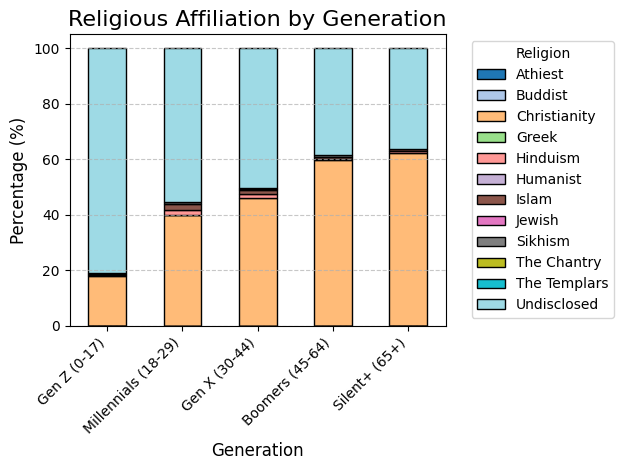

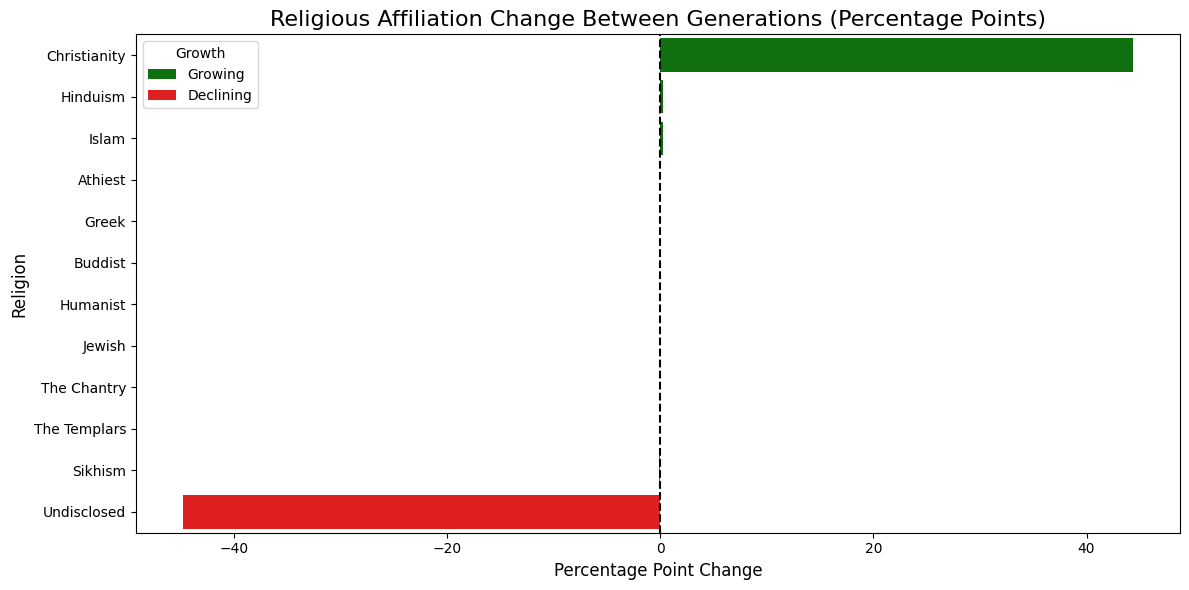

<Figure size 1200x600 with 0 Axes>

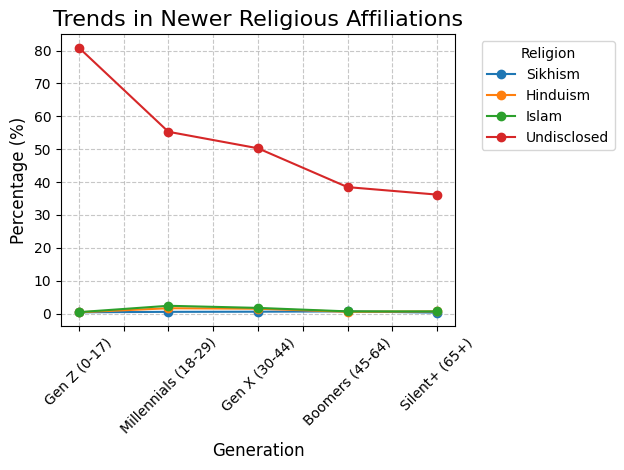


Religious Affiliation Trends Analysis:
-------------------------------------
    Religion  Youngest Gen %  Oldest Gen %  Change (pp)    Growth
Christianity       62.218045     17.900973    44.317072   Growing
    Hinduism        0.657895      0.380872     0.277023   Growing
       Islam        0.657895      0.423191     0.234704   Growing
     Athiest        0.000000      0.000000     0.000000 Declining
       Greek        0.000000      0.000000     0.000000 Declining
     Buddist        0.000000      0.000000     0.000000 Declining
    Humanist        0.000000      0.000000     0.000000 Declining
      Jewish        0.000000      0.000000     0.000000 Declining
 The Chantry        0.000000      0.000000     0.000000 Declining
The Templars        0.000000      0.000000     0.000000 Declining
     Sikhism        0.281955      0.380872    -0.098917 Declining
 Undisclosed       36.184211     80.914092   -44.729882 Declining

Fastest Growing Religion: Christianity (+44.3 pp)
Fastest Decli

C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:302: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marital_dist = df.groupby('age_group')['marital_status'].value_counts(normalize=True).unstack() * 100


<Figure size 1400x800 with 0 Axes>

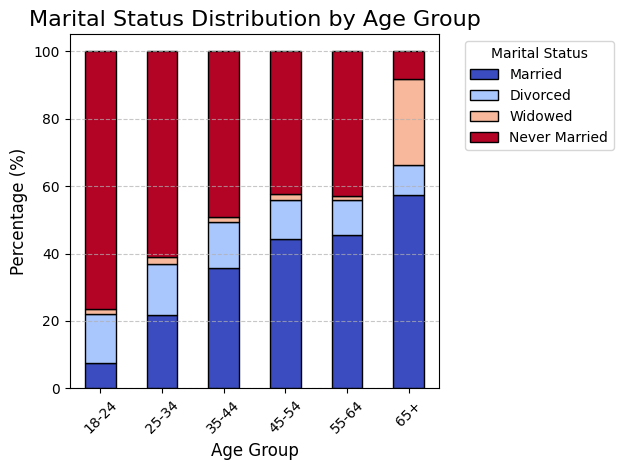

C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:328: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  married_pct = df[df['marital_status'] == 'Married'].groupby('age_group').size() / df.groupby('age_group').size() * 100
C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:328: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  married_pct = df[df['marital_status'] == 'Married'].groupby('age_group').size() / df.groupby('age_group').size() * 100
C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:329: FutureWarning: The default of observed=False is deprecated and will be chang

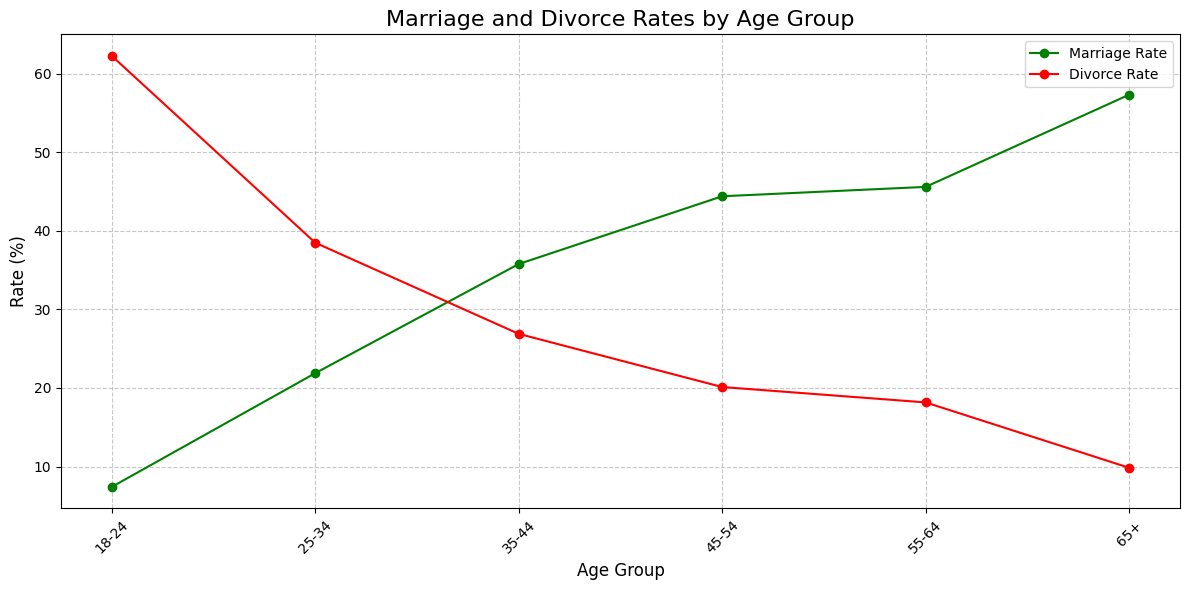

C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:364: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=housing_data, x='Household Type', y='Percentage', palette='viridis')


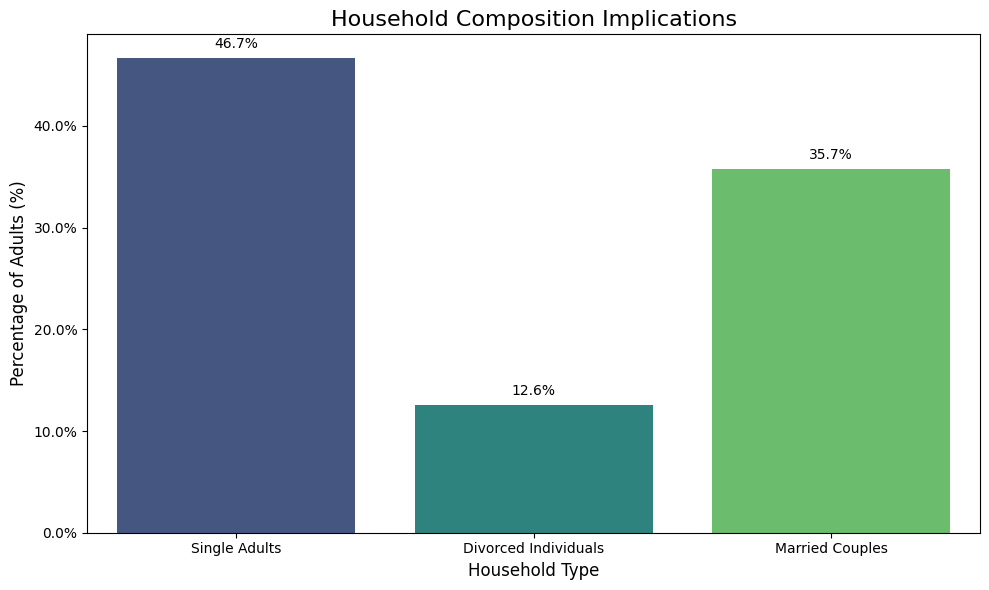


Marriage and Divorce Analysis:
-----------------------------
Overall Marriage Rate: 35.7% of adults
Overall Divorce Rate: 23.5% of ever-married adults

Single Adults: 46.7% of adult population
Divorced Individuals: 12.6% of adult population
Married Couples: 35.7% of potential households

Marital Status by Gender:
------------------------
marital_status  Married  Divorced  Never Married
gender                                          
Female             33.7      14.2           45.9
Male               38.1      10.6           47.5

Results saved to CSV files


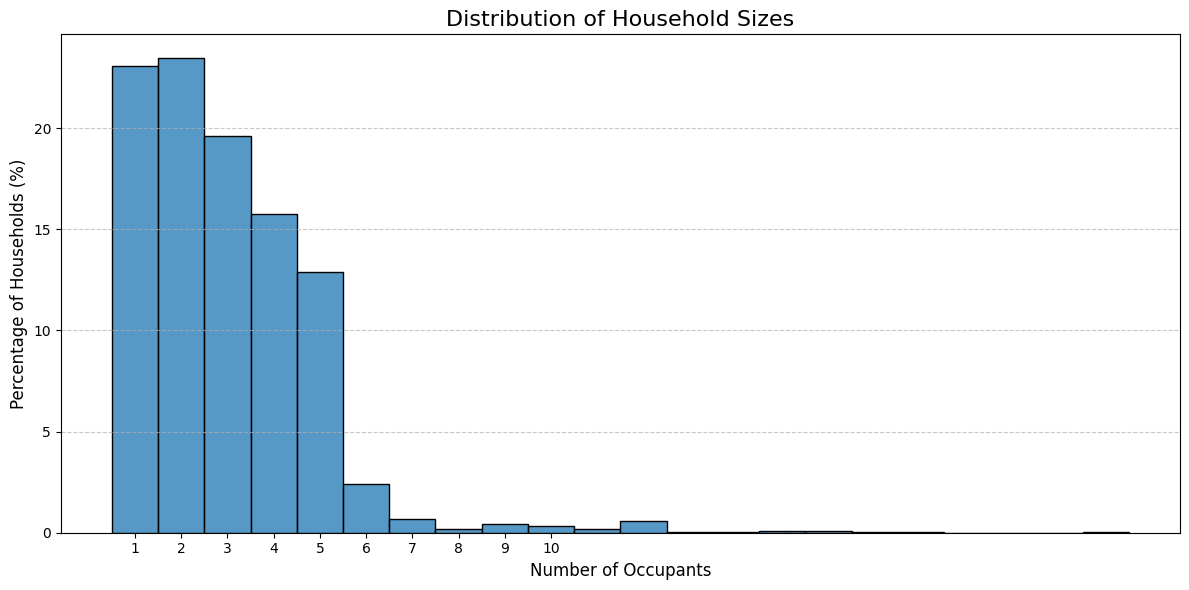


Household Occupancy Statistics:
-------------------------------
Average household size: 2.99 people
Median household size: 3.0 people
Most common household size: 2 people

The average household has 0.49 more people than standard (over-utilization)


C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:467: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(family_size, label='Family Households', shade=True)
C:\Users\Goeasy\AppData\Local\Temp\ipykernel_17612\2172468307.py:468: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(non_family_size, label='Non-Family Households', shade=True)


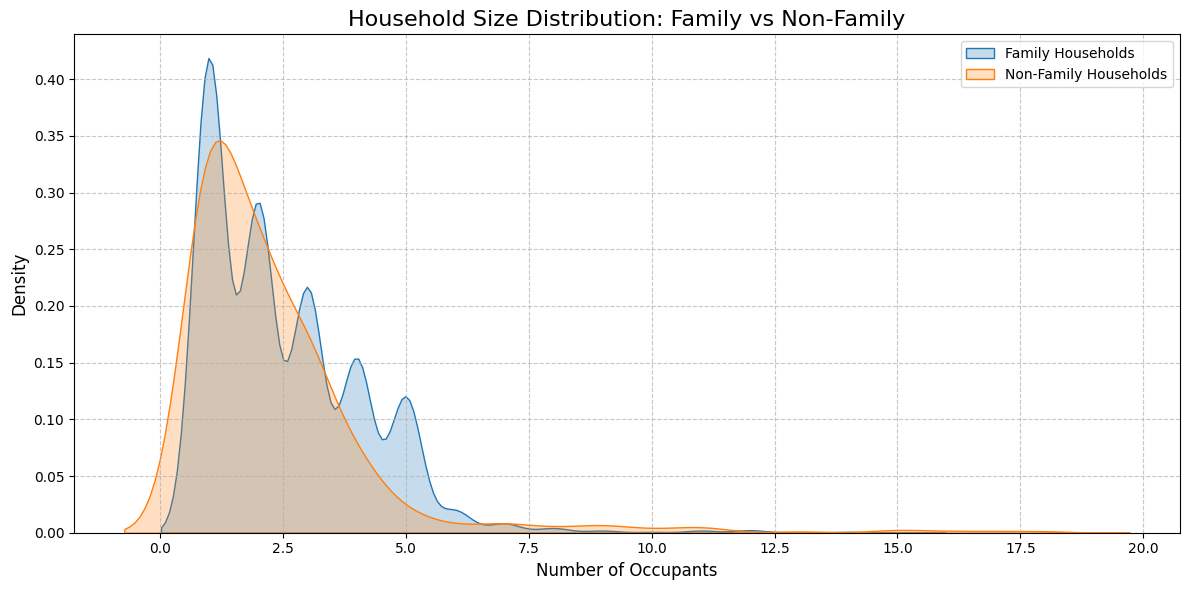


Results saved to CSV files
=== University Student Analysis ===
Total University/PhD Students: 630

Age Distribution of University Students:
count    630.000000
mean      20.542857
std        1.685222
min       18.000000
25%       19.000000
50%       20.000000
75%       21.000000
max       32.000000
Name: age, dtype: float64

=== Commuting Profession Analysis ===
Top 20 Likely Commuting Professions:
University Student: 617
Hotel manager: 18
Records manager: 17
Research scientist (medical): 16
Scientist, research (medical): 16
Lecturer, higher education: 15
Theatre director: 15
Communications engineer: 15
Scientist, product/process development: 15
Engineer, drilling: 14
Engineer, control and instrumentation: 14
Interior and spatial designer: 14
Sports administrator: 14
Graphic designer: 13
Engineer, land: 13
Housing manager/officer: 13
Contracting civil engineer: 13
Scientist, marine: 13
Chief Executive Officer: 13
Education administrator: 13

Total working population: 7286
Likely commu

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_excel('cleaned_census_data.xlsx')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data (assuming it's in a CSV file)
df = pd.read_excel('cleaned_census_data.xlsx')  # or pd.read_csv if CSV

# Create age groups
bins = [0, 4, 9, 14, 17, 24, 34, 44, 54, 64, 74, 84, 120]
labels = ['0-4', '5-9', '10-14', '15-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-84', '85+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Split by gender
male = df[df['gender'] == 'Male']
female = df[df['gender'] == 'Female']

# Create population pyramid
def create_population_pyramid(male, female, age_groups):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Male population (left side)
    male_counts = male['age_group'].value_counts().reindex(age_groups, fill_value=0)
    ax.barh(age_groups, -male_counts, color='skyblue', label='Male')
    
    # Female population (right side)
    female_counts = female['age_group'].value_counts().reindex(age_groups, fill_value=0)
    ax.barh(age_groups, female_counts, color='salmon', label='Female')
    
    # Add labels and title
    ax.set_title('Population Age Pyramid', fontsize=16)
    ax.set_xlabel('Population Count', fontsize=12)
    ax.set_ylabel('Age Groups', fontsize=12)
    ax.legend()
    
    # Format x-axis to show absolute values
    max_pop = max(male_counts.max(), female_counts.max())
    x_ticks = np.arange(-max_pop, max_pop+1, max_pop//5)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([abs(x) for x in x_ticks])
    
    # Add population totals
    total_pop = len(df)
    male_percent = len(male)/total_pop * 100
    female_percent = len(female)/total_pop * 100
    plt.text(0.95, 0.95, f'Total Population: {total_pop}\nMale: {male_percent:.1f}%\nFemale: {female_percent:.1f}%', 
             transform=ax.transAxes, ha='right', va='top', 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('population_pyramid.png')
    plt.show()

# Generate the pyramid
create_population_pyramid(male, female, labels)

# Additional analysis
print("\nAge Distribution Analysis:")
print("-------------------------")
print(f"Total population: {len(df)}")
print(f"Children (0-17): {len(df[df['age'] < 18])} ({len(df[df['age'] < 18])/len(df)*100:.1f}%)")
print(f"Working age (18-64): {len(df[(df['age'] >= 18) & (df['age'] < 65)])} ({len(df[(df['age'] >= 18) & (df['age'] < 65)])/len(df)*100:.1f}%)")
print(f"Seniors (65+): {len(df[df['age'] >= 65])} ({len(df[df['age'] >= 65])/len(df)*100:.1f}%)")

# Dependency ratios
working_age = len(df[(df['age'] >= 18) & (df['age'] < 65)])
child_dependency = len(df[df['age'] < 18]) / working_age
senior_dependency = len(df[df['age'] >= 65]) / working_age

print("\nDependency Ratios:")
print(f"Child dependency ratio (children per working-age adult): {child_dependency:.2f}")
print(f"Senior dependency ratio (seniors per working-age adult): {senior_dependency:.2f}")
print(f"Total dependency ratio: {child_dependency + senior_dependency:.2f}")

# Future projections
current_45_64 = len(df[(df['age'] >= 45) & (df['age'] < 65)])
print(f"\nPotential retirees in next 20 years (current 45-64 year olds): {current_45_64}")

# Save the plot
plt.savefig('age_pyramid.png')
print("\nPopulation pyramid saved as 'age_pyramid.png'")


## 2. Unemployment Analysis
# Identify unemployed individuals
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_excel('cleaned_census_data.xlsx')  # or pd.read_csv() if CSV

# Define unemployed - assuming 'Unemployed' is in occupation column
df['is_unemployed'] = df['occupation'].str.lower().str.contains('unemployed')

# Create age groups
bins = [0, 17, 24, 34, 44, 54, 64, 120]
labels = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Calculate unemployment by age group
unemployment = df.groupby('age_group')['is_unemployed'].agg(['sum', 'count'])
unemployment['unemployment_rate'] = (unemployment['sum'] / unemployment['count']) * 100
unemployment = unemployment.reset_index()

# Plot unemployment by age group
plt.figure(figsize=(12, 6))
bars = plt.bar(unemployment['age_group'], unemployment['unemployment_rate'], 
               color='royalblue', edgecolor='black')

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom')

plt.title('Unemployment Rate by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('unemployment_by_age.png')
plt.show()

# Additional analysis by gender
df['gender'] = df['gender'].str.title()  # Standardize gender labels
gender_unemployment = df.groupby(['age_group', 'gender'])['is_unemployed'].agg(['sum', 'count'])
gender_unemployment['unemployment_rate'] = (gender_unemployment['sum'] / gender_unemployment['count']) * 100
gender_unemployment = gender_unemployment.reset_index()

# Plot unemployment by age and gender
pivot_data = gender_unemployment.pivot(index='age_group', columns='gender', values='unemployment_rate')
pivot_data.plot(kind='bar', figsize=(12, 6), color=['salmon', 'skyblue'], edgecolor='black')
plt.title('Unemployment Rate by Age Group and Gender', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('unemployment_by_age_gender.png')
plt.show()

# Detailed statistics
print("\nUnemployment Analysis by Age Group:")
print("----------------------------------")
print(unemployment[['age_group', 'sum', 'count', 'unemployment_rate']]
      .rename(columns={'sum': 'Unemployed', 'count': 'Total', 'unemployment_rate': 'Rate (%)'}))

print("\nUnemployment by Age Group and Gender:")
print("-------------------------------------")
print(gender_unemployment[['age_group', 'gender', 'sum', 'count', 'unemployment_rate']]
      .rename(columns={'sum': 'Unemployed', 'count': 'Total', 'unemployment_rate': 'Rate (%)'}))

# Find age group with highest unemployment
max_unemp = unemployment.loc[unemployment['unemployment_rate'].idxmax()]
print(f"\nHighest unemployment rate is in age group {max_unemp['age_group']} at {max_unemp['unemployment_rate']:.1f}%")

# Calculate correlation between age and unemployment
correlation = df['age'].corr(df['is_unemployed'].astype(int))
print(f"\nCorrelation between age and unemployment: {correlation:.2f}")

# Save results to CSV
unemployment.to_csv('unemployment_by_age.csv', index=False)
gender_unemployment.to_csv('unemployment_by_age_gender.csv', index=False)
print("\nResults saved to CSV files")

#Examine religious affiliations. Are any religions growing, or shrinking? Are there any newer religions that are increasing in numbers?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Load the data
df = pd.read_excel('cleaned_census_data.xlsx')  # or pd.read_csv() if CSV

# Clean and standardize religion data
df['religion'] = df['religion'].str.title().replace({
    'None': 'Unaffiliated',
    'Unknown': 'Undisclosed',
    'Christian': 'Christianity',
    'Sikh': 'Sikhism',
    'Hindu': 'Hinduism',
    'Muslim': 'Islam',
    '': 'Undisclosed'
}).fillna('Undisclosed')

# Create age cohorts for generational analysis
cohort_bins = [0, 17, 29, 44, 64, 120]
cohort_labels = ['Gen Z (0-17)', 'Millennials (18-29)', 'Gen X (30-44)', 
                'Boomers (45-64)', 'Silent+ (65+)']
df['generation'] = pd.cut(df['age'], bins=cohort_bins, labels=cohort_labels, right=False)

# Analyze religious distribution by generation
religion_by_gen = df.groupby(['generation', 'religion']).size().unstack().fillna(0)
religion_pct = religion_by_gen.div(religion_by_gen.sum(axis=1), axis=0) * 100

# Plot religious distribution by generation
plt.figure(figsize=(14, 8))
religion_pct.plot(kind='bar', stacked=True, colormap='tab20', edgecolor='black')
plt.title('Religious Affiliation by Generation', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Religion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('religion_by_generation.png', bbox_inches='tight')
plt.show()

# Calculate growth/decline trends
religion_trends = defaultdict(list)
current_gen = religion_pct.index[-1]  # Youngest generation
oldest_gen = religion_pct.index[0]   # Oldest generation

for religion in religion_pct.columns:
    current_pct = religion_pct.loc[current_gen, religion]
    oldest_pct = religion_pct.loc[oldest_gen, religion]
    change = current_pct - oldest_pct
    religion_trends['Religion'].append(religion)
    religion_trends['Youngest Gen %'].append(current_pct)
    religion_trends['Oldest Gen %'].append(oldest_pct)
    religion_trends['Change (pp)'].append(change)
    religion_trends['Growth'].append('Growing' if change > 0 else 'Declining')

trend_df = pd.DataFrame(religion_trends).sort_values('Change (pp)', ascending=False)

# Plot top growing/declining religions
plt.figure(figsize=(12, 6))
sns.barplot(data=trend_df, x='Change (pp)', y='Religion', hue='Growth', 
            palette={'Growing': 'green', 'Declining': 'red'}, dodge=False)
plt.title('Religious Affiliation Change Between Generations (Percentage Points)', fontsize=16)
plt.xlabel('Percentage Point Change', fontsize=12)
plt.ylabel('Religion', fontsize=12)
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('religion_growth_trends.png')
plt.show()

# Analyze newer religious movements
new_religions = ['Sikhism', 'Hinduism', 'Islam', 'Undisclosed']  # Add others as needed
new_religion_trends = religion_pct[new_religions]

plt.figure(figsize=(12, 6))
new_religion_trends.plot(marker='o')
plt.title('Trends in Newer Religious Affiliations', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Religion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('new_religions_trend.png', bbox_inches='tight')
plt.show()

# Print key findings
print("\nReligious Affiliation Trends Analysis:")
print("-------------------------------------")
print(trend_df[['Religion', 'Youngest Gen %', 'Oldest Gen %', 'Change (pp)', 'Growth']]
      .sort_values('Change (pp)', ascending=False).to_string(index=False))

fastest_growing = trend_df.iloc[0]
fastest_declining = trend_df.iloc[-1]
print(f"\nFastest Growing Religion: {fastest_growing['Religion']} (+{fastest_growing['Change (pp)']:.1f} pp)")
print(f"Fastest Declining Religion: {fastest_declining['Religion']} ({fastest_declining['Change (pp)']:.1f} pp)")

# Save results to CSV
religion_pct.to_csv('religion_by_generation.csv')
trend_df.to_csv('religion_growth_trends.csv', index=False)
print("\nResults saved to CSV files")

#Examine the divorce and marriage rate. This might impact how you think about housing.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Load the data
df = pd.read_excel('cleaned_census_data.xlsx')  # or pd.read_csv() if CSV

# Clean marital status data
df['marital_status'] = df['marital_status'].str.title().replace({
    'Single': 'Never Married',
    'Unknown': 'Undisclosed',
    '': 'Undisclosed'
}).fillna('Undisclosed')

# Create age groups for analysis
age_bins = [0, 24, 34, 44, 54, 64, 120]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df = df[df['age'] >= 18]  # Focus on adults
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Calculate marital status distribution
marital_dist = df.groupby('age_group')['marital_status'].value_counts(normalize=True).unstack() * 100

# Plot marital status by age group
plt.figure(figsize=(14, 8))
marital_dist[['Married', 'Divorced', 'Widowed', 'Never Married']].plot(
    kind='bar', stacked=True, colormap='coolwarm', edgecolor='black')
plt.title('Marital Status Distribution by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Marital Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('marital_status_by_age.png', bbox_inches='tight')
plt.show()

# Calculate marriage and divorce rates
total_adults = len(df)
married_count = len(df[df['marital_status'] == 'Married'])
divorced_count = len(df[df['marital_status'] == 'Divorced'])
ever_married = len(df[df['marital_status'].isin(['Married', 'Divorced', 'Widowed'])])

marriage_rate = married_count / total_adults * 100
divorce_rate = divorced_count / ever_married * 100 if ever_married > 0 else 0

# Plot marriage and divorce rates by age
married_pct = df[df['marital_status'] == 'Married'].groupby('age_group').size() / df.groupby('age_group').size() * 100
divorced_pct = df[df['marital_status'] == 'Divorced'].groupby('age_group').size() / df[df['marital_status'].isin(['Married', 'Divorced', 'Widowed'])].groupby('age_group').size() * 100

plt.figure(figsize=(12, 6))
married_pct.plot(kind='line', marker='o', color='green', label='Marriage Rate')
divorced_pct.plot(kind='line', marker='o', color='red', label='Divorce Rate')
plt.title('Marriage and Divorce Rates by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('marriage_divorce_rates.png')
plt.show()

# Housing implications analysis
# 1. Single-person households
single_adults = len(df[df['marital_status'] == 'Never Married'])
single_share = single_adults / total_adults * 100

# 2. Divorced individuals potentially needing smaller housing
divorced_housing = len(df[df['marital_status'] == 'Divorced'])
divorced_share = divorced_housing / total_adults * 100

# 3. Married couples potentially needing family housing
married_couples = married_count / 2  # Assuming each marriage represents one household
married_share = married_couples / (total_adults / 2) * 100  # Household percentage

# Plot housing implications
housing_data = pd.DataFrame({
    'Household Type': ['Single Adults', 'Divorced Individuals', 'Married Couples'],
    'Percentage': [single_share, divorced_share, married_share]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=housing_data, x='Household Type', y='Percentage', palette='viridis')
plt.title('Household Composition Implications', fontsize=16)
plt.xlabel('Household Type', fontsize=12)
plt.ylabel('Percentage of Adults (%)', fontsize=12)
plt.gca().yaxis.set_major_formatter(PercentFormatter())
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%', 
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10),
                       textcoords='offset points')
plt.tight_layout()
plt.savefig('housing_implications.png')
plt.show()

# Print key findings
print("\nMarriage and Divorce Analysis:")
print("-----------------------------")
print(f"Overall Marriage Rate: {marriage_rate:.1f}% of adults")
print(f"Overall Divorce Rate: {divorce_rate:.1f}% of ever-married adults")
print(f"\nSingle Adults: {single_share:.1f}% of adult population")
print(f"Divorced Individuals: {divorced_share:.1f}% of adult population")
print(f"Married Couples: {married_share:.1f}% of potential households")

# Marriage/divorce by gender
gender_marital = df.groupby(['gender', 'marital_status']).size().unstack()
gender_marital_pct = gender_marital.div(gender_marital.sum(axis=1), axis=0) * 100

print("\nMarital Status by Gender:")
print("------------------------")
print(gender_marital_pct[['Married', 'Divorced', 'Never Married']].round(1))

# Save results to CSV
marital_dist.to_csv('marital_status_by_age.csv')
housing_data.to_csv('housing_implications.csv', index=False)
print("\nResults saved to CSV files")

#Examine the occupancy level (how many people per house) and determine if existing housing is being under or over-used.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_excel('cleaned_census_data.xlsx')  # or pd.read_csv() if CSV

# Create a unique household identifier (combining address fields)
df['household_id'] = df['house_number'].astype(str) + '_' + df['street']

# Calculate people per household
household_size = df.groupby('household_id').size().reset_index(name='occupants')

# Analyze occupancy distribution
plt.figure(figsize=(12, 6))
sns.histplot(household_size['occupants'], bins=range(1, 11), discrete=True, stat='percent')
plt.title('Distribution of Household Sizes', fontsize=16)
plt.xlabel('Number of Occupants', fontsize=12)
plt.ylabel('Percentage of Households (%)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('household_size_distribution.png')
plt.show()

# Calculate summary statistics
mean_occupancy = household_size['occupants'].mean()
median_occupancy = household_size['occupants'].median()
mode_occupancy = household_size['occupants'].mode()[0]

print("\nHousehold Occupancy Statistics:")
print("-------------------------------")
print(f"Average household size: {mean_occupancy:.2f} people")
print(f"Median household size: {median_occupancy} people")
print(f"Most common household size: {mode_occupancy} people")

# Compare to standard housing assumptions
standard_occupancy = 2.5  # Common planning standard
occupancy_diff = mean_occupancy - standard_occupancy

if occupancy_diff > 0:
    print(f"\nThe average household has {occupancy_diff:.2f} more people than standard (over-utilization)")
else:
    print(f"\nThe average household has {-occupancy_diff:.2f} fewer people than standard (under-utilization)")

# Analyze by housing type (if available)
if 'house_type' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='house_type', y=df.groupby('household_id')['household_id'].transform('count'))
    plt.title('Household Size by Housing Type', fontsize=16)
    plt.xlabel('Housing Type', fontsize=12)
    plt.ylabel('Number of Occupants', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('occupancy_by_housing_type.png')
    plt.show()

# Analyze by family composition
family_houses = df[df['relationship_to_head_of_house'].isin(['Head', 'Spouse/Partner', 'Child'])]
family_size = family_houses.groupby('household_id').size()
non_family_houses = df[~df['relationship_to_head_of_house'].isin(['Head', 'Spouse/Partner', 'Child'])]
non_family_size = non_family_houses.groupby('household_id').size()

plt.figure(figsize=(12, 6))
sns.kdeplot(family_size, label='Family Households', shade=True)
sns.kdeplot(non_family_size, label='Non-Family Households', shade=True)
plt.title('Household Size Distribution: Family vs Non-Family', fontsize=16)
plt.xlabel('Number of Occupants', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('family_vs_nonfamily_occupancy.png')
plt.show()

# Calculate room utilization (if room data is available)
if 'number_of_rooms' in df.columns:
    # Get unique rooms per household (assuming same for all members)
    household_rooms = df.drop_duplicates('household_id')[['household_id', 'number_of_rooms']]
    utilization = pd.merge(household_size, household_rooms, on='household_id')
    utilization['persons_per_room'] = utilization['occupants'] / utilization['number_of_rooms']
    
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=utilization, x='number_of_rooms', y='occupants', alpha=0.6)
    plt.title('Household Size vs Number of Rooms', fontsize=16)
    plt.xlabel('Number of Rooms', fontsize=12)
    plt.ylabel('Number of Occupants', fontsize=12)
    plt.grid(linestyle='--', alpha=0.7)
    
    # Add reference lines for common standards
    plt.axline((0, 0), slope=0.5, color='red', linestyle='--', label='0.5 persons/room')
    plt.axline((0, 0), slope=1, color='green', linestyle='--', label='1 person/room')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('room_utilization.png')
    plt.show()
    
    print("\nRoom Utilization Analysis:")
    print("--------------------------")
    print(f"Average persons per room: {utilization['persons_per_room'].mean():.2f}")
    overcrowded = len(utilization[utilization['persons_per_room'] > 1]) / len(utilization) * 100
    underutilized = len(utilization[utilization['persons_per_room'] < 0.5]) / len(utilization) * 100
    print(f"Percentage of overcrowded households (>1 person/room): {overcrowded:.1f}%")
    print(f"Percentage of underutilized households (<0.5 persons/room): {underutilized:.1f}%")

# Save results
household_size.to_csv('household_occupancy.csv', index=False)
print("\nResults saved to CSV files")


#Examine the number of university students. All of these are commuters since there are no universities in the town. Are there any other professions that are likely to be commuters?

import pandas as pd
from collections import Counter

def analyze_commuting_professions(data):
    """
    Analyze commuting patterns in the census data by identifying:
    1. University students who must commute
    2. Other professions likely requiring commuting
    """
    # 1. Count university students
    uni_students = data[data['occupation'].str.contains('University Student|PhD Student', case=False, na=False)]
    uni_student_count = len(uni_students)
    
    print("=== University Student Analysis ===")
    print(f"Total University/PhD Students: {uni_student_count}")
    print("\nAge Distribution of University Students:")
    print(uni_students['age'].describe())
    
    # 2. Analyze other likely commuting professions
    commuting_keywords = [
        'university', 'professor', 'lecturer', 'academic', 
        'hospital', 'surgeon', 'doctor', 'physician', 'nurse', 'specialist',
        'engineer', 'scientist', 'researcher', 'analyst',
        'financial', 'banker', 'broker', 'trader', 'investment',
        'government', 'civil service', 'administrator',
        'architect', 'designer', 'artist',
        'manager', 'executive', 'director',
        'technician', 'technologist', 'consultant',
        'analyst', 'therapist', 'psychologist'
    ]
    
    # Get all working adults (excluding students and children)
    working_population = data[~data['occupation'].isin(['Student', 'Child'])]
    
    # Identify likely commuters
    commuting_professions = []
    for index, row in working_population.iterrows():
        occupation = str(row['occupation']).lower()
        if any(kw.lower() in occupation for kw in commuting_keywords):
            commuting_professions.append(row['occupation'])
    
    # Count occurrences of each commuting profession
    profession_counts = Counter(commuting_professions)
    
    # Get top 20 most common commuting professions
    top_commuting = profession_counts.most_common(20)
    
    print("\n=== Commuting Profession Analysis ===")
    print("Top 20 Likely Commuting Professions:")
    for profession, count in top_commuting:
        print(f"{profession}: {count}")
    
    # Calculate commuter statistics
    total_workers = len(working_population)
    likely_commuters = len(commuting_professions)
    
    print(f"\nTotal working population: {total_workers}")
    print(f"Likely commuters (excluding students): {likely_commuters}")
    print(f"Percentage of workers who likely commute: {likely_commuters/total_workers*100:.1f}%")
    
    return uni_student_count, top_commuting

# Load the dataset
df = pd.read_excel('cleaned_census_data.xlsx')

# Run the analysis
uni_students, commuting_professions = analyze_commuting_professions(df)
        
## 7. Birth and Death Rate Analysis

import pandas as pd

# Load the dataset
df = pd.read_excel('cleaned_census_data.xlsx')

# Calculate birth rate (approximation)
infants = df[df['age'] == 0]  # Count infants (age=0) as recent births
birth_rate = len(infants) / len(df) * 1000  # Births per 1000 population

# Estimate death rate (requires assumptions)
# Assuming average lifespan of 80 years and stable population
death_rate = (len(df)/80) / len(df) * 1000  # Deaths per 1000 population (simplified)

print(f"Estimated Birth Rate: {birth_rate:.2f} per 1000 population")
print(f"Estimated Death Rate: {death_rate:.2f} per 1000 population")
